# Laboratorio 1: Series de Tiempo
**CC3084 - Data Science | UVG | Semestre II 2026**

Análisis del ingreso de viajeros internacionales a Guatemala (2009 - jun 2026).

Integrantes: Iris Ayala 23960, Jonathan Díaz 23837 y Anggie Quezada 23643

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (11, 4)
pd.set_option('display.max_columns', None)
import logging
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')
warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)


#### Cargar datos

In [2]:
df = pd.read_excel('Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx', sheet_name='Datos')
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
print(df.shape)
df.head()

(161036, 14)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


### Análisis exploratorio 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Año                    161036 non-null  int64         
 1   Mes cod                161036 non-null  int64         
 2   Mes                    161036 non-null  str           
 3   Vía                    161036 non-null  str           
 4   Frontera               161036 non-null  str           
 5   País                   161036 non-null  str           
 6   Región                 161036 non-null  str           
 7   Región dos             161036 non-null  str           
 8   Regiones OMT           161036 non-null  str           
 9   MCEO                   161036 non-null  str           
 10  Agrupación Residencia  161036 non-null  str           
 11  Tipo de Viajero        161036 non-null  str           
 12  Viajero                161036 non-null  float64       


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Año,161036.0,NaN,NaN,NaN,2016.017543,2009.0,2012.0,2016.0,2019.0,2026.0,4.552887
Mes cod,161036.0,NaN,NaN,NaN,6.416075,1.0,3.0,6.0,10.0,12.0,3.531936
Mes,161036,12,Ene,14726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vía,161036,3,Terrestre,125873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frontera,161036,22,01 La Aurora,21424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,161036,235,Guatemala,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región,161036,17,EUROPA,32331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región dos,161036,11,Europa,54640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiones OMT,161036,26,AMÉRICA CENTRAL,31362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCEO,161036,8,08 OTROS,73173,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Comportamiento temporal del número de viajeros

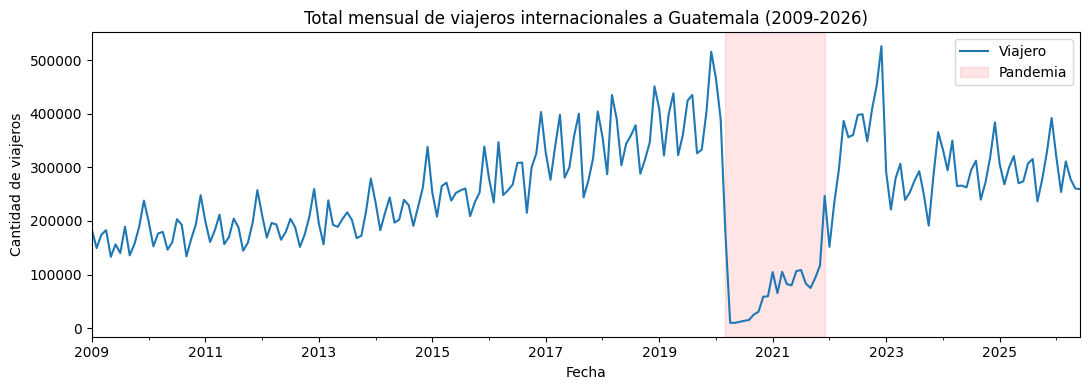

In [5]:
serie_total = df.groupby('Fecha')['Viajero'].sum().sort_index()

fig, ax = plt.subplots()
serie_total.plot(ax=ax)
ax.set_title('Total mensual de viajeros internacionales a Guatemala (2009-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de viajeros')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='red', alpha=0.1, label='Pandemia')
ax.legend()
plt.tight_layout()
plt.show()


Se ve una tendencia creciente desde 2009 hasta 2019. Después hay una caída bien fuerte
en marzo de 2020, que es cuando cerraron fronteras por la pandemia. Se mantiene bajo como
un año y medio y luego empieza a recuperarse en 2022. También se nota un cambio de nivel
entre 2022 y 2023.

#### Mayor cantidad de viajeros

In [6]:
top_paises = df.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(10)
top_paises


País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
México                       1.808946e+06
Belice                       1.328256e+06
Nicaragua                    1.164343e+06
Cruceristas                  1.078372e+06
Costa Rica                   8.821797e+05
Colombia                     5.610353e+05
Name: Viajero, dtype: float64

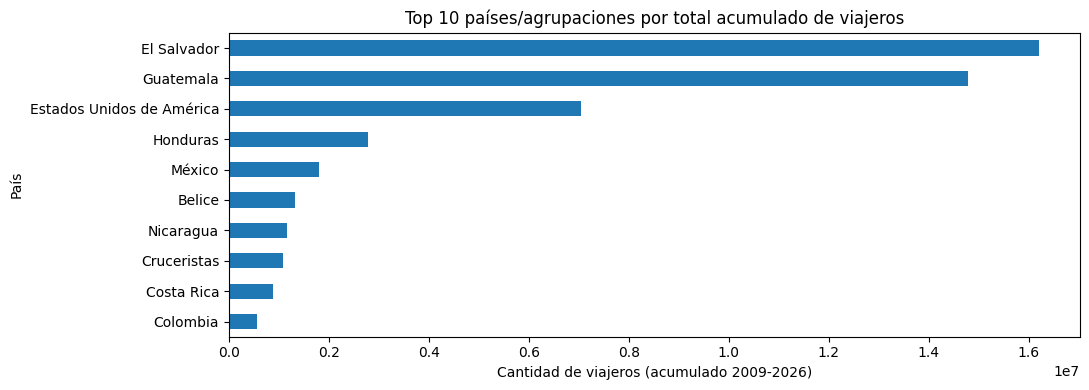

In [7]:
fig, ax = plt.subplots()
top_paises.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 países/agrupaciones por total acumulado de viajeros')
ax.set_xlabel('Cantidad de viajeros (acumulado 2009-2026)')
plt.tight_layout()
plt.show()

El Salvador y Guatemala son los que más viajeros aportan, seguidos de Estados Unidos, Honduras y México. Con esto queda claro que la mayoría del movimiento es centroamericano y no tanto turismo internacional de otros continentes. Ojo que desde 2023 ya no se reporta cada país individual sino agrupaciones de mercado, entonces comparar país por país antes y después de 2023 hay que hacerlo con cuidado.


#### Regiones con mayor cantidad de viajeros

In [8]:
top_regiones = df.groupby('Región dos')['Viajero'].sum().sort_values(ascending=False)
top_regiones

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.078372e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Cruceros                       2.603000e+04
Otros Paises Del Mundo         2.511115e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

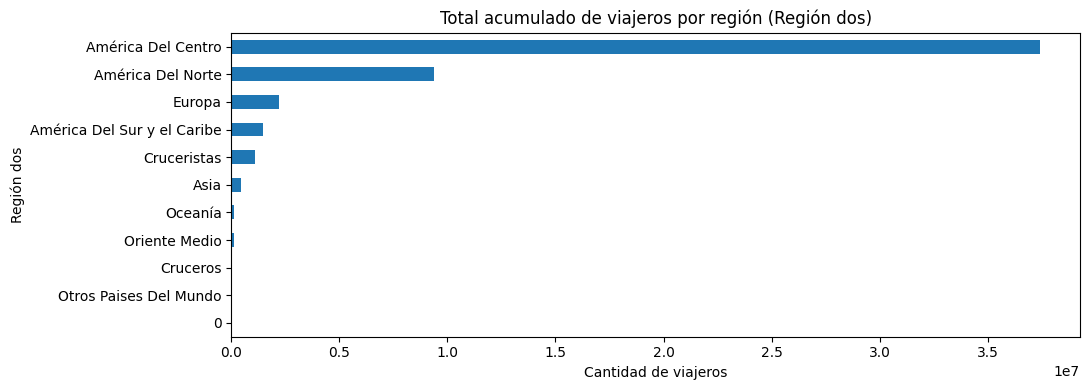

In [9]:
fig, ax = plt.subplots()
top_regiones.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Total acumulado de viajeros por región (Región dos)')
ax.set_xlabel('Cantidad de viajeros')
plt.tight_layout()
plt.show()

América del Centro es la región que más aporta, muy por encima de las demás, luego
América del Norte y después Europa. Esto va de la mano con lo que vimos en países: el
grueso de los viajeros es movimiento regional, no turismo de larga distancia. Hay dos
categorías rarísimas  que casi no pesan nada en el total, seguro son
registros mal clasificados pero no cambian las conclusiones.


#### Vías de ingreso y fronteras más utilizadas

In [10]:
via_totales = df.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
frontera_totales = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(10)
print(via_totales)
print()
print(frontera_totales)


Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64

Frontera
01 La Aurora                     1.903440e+07
07 Valle Nuevo                   1.073234e+07
09 San Cristóbal                 5.363009e+06
08 Pedro de Alvarado             4.393577e+06
10 La Ermita (Nueva Anguiatú)    2.879210e+06
20 Melchor de Mencos             2.349551e+06
13 El Cinchado / El Corinto      1.497006e+06
12 El Florido                    1.221040e+06
11 Agua Caliente                 1.154542e+06
15 El Carmen                     1.023092e+06
Name: Viajero, dtype: float64


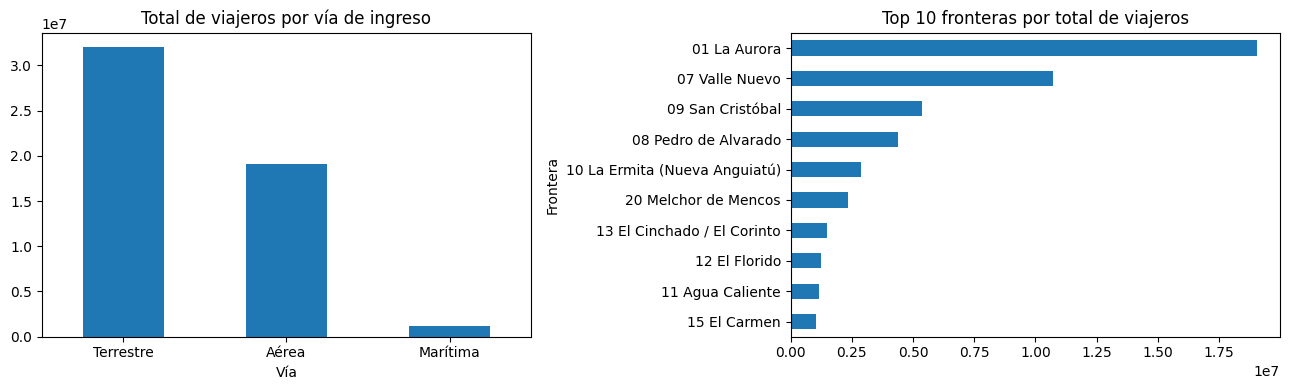

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
via_totales.plot(kind='bar', ax=axes[0])
axes[0].set_title('Total de viajeros por vía de ingreso')
axes[0].tick_params(axis='x', rotation=0)

frontera_totales.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 10 fronteras por total de viajeros')
plt.tight_layout()
plt.show()

La vía Terrestre es la que más se usa por mucho, lo cual tiene sentido porque coincide
con que El Salvador, Honduras y México son los países con más movimiento. La vía Aérea es
la segunda y la Marítima es la que menos se usa. En fronteras, "01 La Aurora" (el
aeropuerto) y "07 Valle Nuevo" (frontera con El Salvador) son las más usadas.

#### Valores faltantes, duplicados y valores atípicos

In [12]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Filas totalmente duplicadas:', df.duplicated().sum())

Valores nulos por columna:
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
Fecha                    0
dtype: int64



Filas totalmente duplicadas: 0


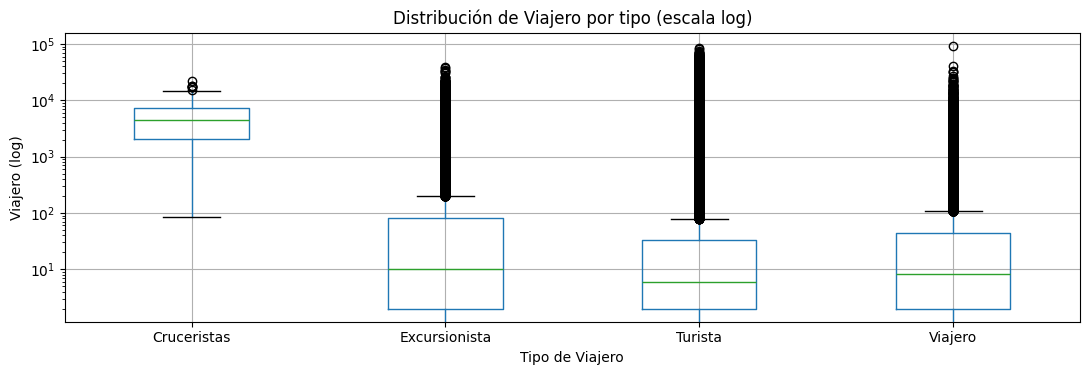

In [13]:
fig, ax = plt.subplots()
df.boxplot(column='Viajero', by='Tipo de Viajero', ax=ax, rot=0)
ax.set_yscale('log')
ax.set_title('Distribución de Viajero por tipo (escala log)')
plt.suptitle('')
ax.set_ylabel('Viajero (log)')
plt.tight_layout()
plt.show()

In [14]:
df['Viajero'].describe()


count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

No hay valores nulos ni filas duplicadas, el dataset ya viene limpio. Sí hay valores
que a simple vista parecen atípicos, como registros de 1 o 2 personas junto a registros de
miles, pero es normal porque se están mezclando países muy distintos en volumen. También
vimos en las notas que algunos valores de Viajero desde 2021 son decimales porque salen de
una estimación de encuesta y no de un conteo exacto, así que esas pequeñas diferencias no
son atípicos reales.


#### Estadística descriptiva

In [15]:
resumen_anual = df.groupby('Año')['Viajero'].sum()
resumen_anual


Año
2009    2.028776e+06
2010    2.152899e+06
2011    2.231456e+06
2012    2.299816e+06
2013    2.432169e+06
2014    2.762602e+06
2015    3.041643e+06
2016    3.496217e+06
2017    3.921460e+06
2018    4.256349e+06
2019    4.691820e+06
2020    1.266340e+06
2021    1.267768e+06
2022    4.316164e+06
2023    3.248709e+06
2024    3.593876e+06
2025    3.597238e+06
2026    1.682636e+06
Name: Viajero, dtype: float64

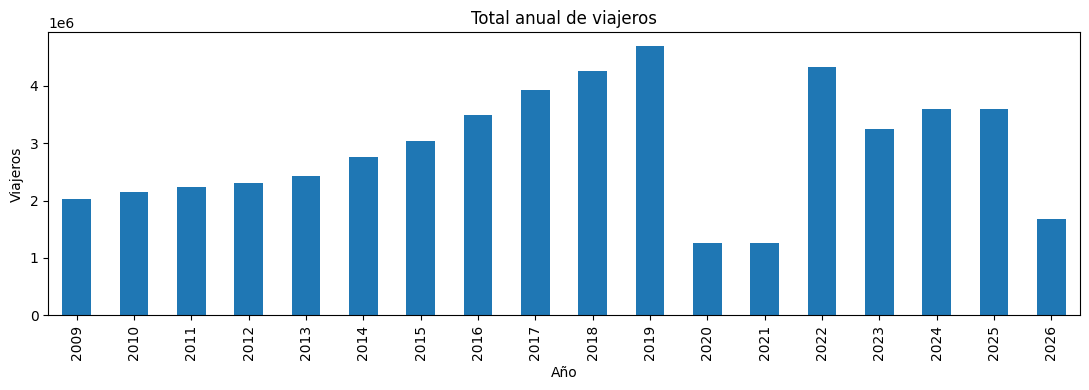

In [16]:
fig, ax = plt.subplots()
resumen_anual.plot(kind='bar', ax=ax)
ax.set_title('Total anual de viajeros')
ax.set_ylabel('Viajeros')
plt.tight_layout()
plt.show()

A nivel anual se ve clarísimo lo que veníamos comentando: la caída de 2020, la
recuperación en 2021-2022, y el salto de nivel en 2023 por el cambio de metodología. Para
comparar años de forma justa en todo el rango conviene usar Turista + Excursionista en vez
del total.

### División en entrenamiento y prueba

Al ser una serie de tiempo no podemos dividir aleatorio, hay que respetar el orden en el
tiempo. Usamos el primer 70% de los meses para entrenamiento y el 30% final para prueba.


In [17]:
meses = serie_total.index.sort_values()
n_train = int(len(meses) * 0.7)
fecha_corte = meses[n_train - 1]

print('Total de meses:', len(meses))
print('Meses de entrenamiento:', n_train, '-> hasta', fecha_corte.strftime('%Y-%m'))
print('Meses de prueba:', len(meses) - n_train, '-> desde', meses[n_train].strftime('%Y-%m'), 'hasta', meses[-1].strftime('%Y-%m'))

df_train = df[df['Fecha'] <= fecha_corte].copy()
df_test  = df[df['Fecha']  > fecha_corte].copy()
print(df_train.shape, df_test.shape)

Total de meses: 210
Meses de entrenamiento: 147 -> hasta 2021-03
Meses de prueba: 63 -> desde 2021-04 hasta 2026-06
(131442, 14) (29594, 14)


### Construcción de series de tiempo mensuales (con datos de entrenamiento)

Las categorías que elegimos como grupo son: Fronteras (top 3) y Países de residencia (top 3), además de la serie obligatoria del total mensual. El top 3 de fronteras y de países se calculó sobre el acumulado dentro del set de entrenamiento, no de un año en específico.

#### Serie obligatoria: total mensual

In [18]:
# Serie obligatoria: total mensual
serie_total_train = df_train.groupby('Fecha')['Viajero'].sum().sort_index()
serie_total_train.head()


Fecha
2009-01-01    183505.590535
2009-02-01    149426.253908
2009-03-01    174237.227095
2009-04-01    182842.489917
2009-05-01    133194.667651
Name: Viajero, dtype: float64

#### Series por frontera (Top 3)

Top 3 fronteras: ['01 La Aurora', '07 Valle Nuevo', '09 San Cristóbal']


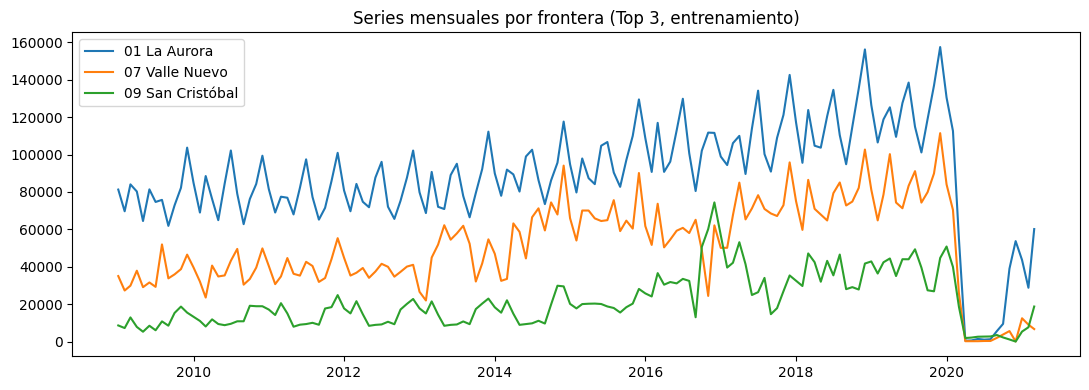

In [19]:
#  Fronteras: Top 3 por acumulado en todo el período
top3_fronteras = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()
print('Top 3 fronteras:', top3_fronteras)

series_frontera = {}
for f in top3_fronteras:
    series_frontera[f] = (df_train[df_train['Frontera'] == f]
                           .groupby('Fecha')['Viajero'].sum()
                           .reindex(serie_total_train.index, fill_value=0))

fig, ax = plt.subplots()
for f, s in series_frontera.items():
    ax.plot(s.index, s.values, label=f)
ax.set_title('Series mensuales por frontera (Top 3, entrenamiento)')
ax.legend()
plt.tight_layout()
plt.show()


Las tres fronteras muestran la misma caída marcada en 2020 y recuperación posterior. La Aurora (aeropuerto) tiene el patrón más estacional por temporadas de vuelos, mientras que Valle Nuevo y San Cristóbal, al ser fronteras terrestres con El Salvador, se ven más estables y con menos variación estacional.

#### Series por país de residencia (Top 3)

Top 3 países: ['El Salvador', 'Guatemala', 'Estados Unidos de América']


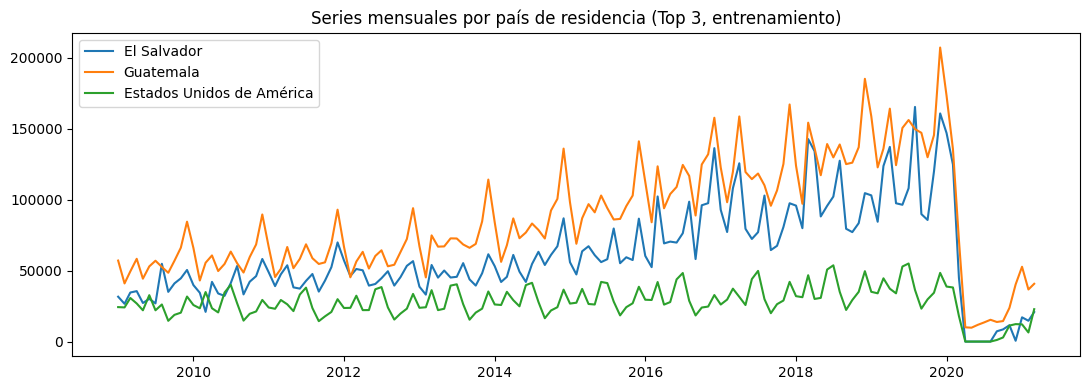

In [20]:
#  Países de residencia: Top 3 por acumulado en todo el período
top3_paises = df.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()
print('Top 3 países:', top3_paises)

series_pais = {}
for p in top3_paises:
    series_pais[p] = (df_train[df_train['País'] == p]
                       .groupby('Fecha')['Viajero'].sum()
                       .reindex(serie_total_train.index, fill_value=0))

fig, ax = plt.subplots()
for p, s in series_pais.items():
    ax.plot(s.index, s.values, label=p)
ax.set_title('Series mensuales por país de residencia (Top 3, entrenamiento)')
ax.legend()
plt.tight_layout()
plt.show()


El Salvador, Guatemala y Estados Unidos de América son los tres países con mayor acumulado en todo el período. Las series muestran la caída de 2020. Guatemala deja de aparecer como país de residencia desde 2023 debido al cambio de cobertura descrito en el dataset; sus ceros posteriores no deben interpretarse como ausencia real de viajeros.

### Análisis de cada serie

In [21]:
def analizar_serie(serie, nombre, periodo=12):
    print(f'--- {nombre} ---')
    print('Inicio:', serie.index.min().strftime('%Y-%m'))
    print('Fin:', serie.index.max().strftime('%Y-%m'))
    print('Frecuencia: mensual (', len(serie), 'observaciones )')
    print()

    fig, ax = plt.subplots()
    serie.plot(ax=ax)
    ax.set_title(f'Serie mensual: {nombre}')
    plt.tight_layout()
    plt.show()

    try:
        desc = seasonal_decompose(serie, model='additive', period=periodo)
        fig = desc.plot()
        fig.set_size_inches(10, 6)
        fig.suptitle(f'Descomposición aditiva: {nombre}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('No se pudo descomponer:', e)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    plot_acf(serie, ax=axes[0], lags=36)
    plot_pacf(serie, ax=axes[1], lags=36, method='ywm')
    plt.tight_layout()
    plt.show()

    resultado_adf = adfuller(serie.dropna())
    print('ADF statistic:', round(resultado_adf[0], 4))
    print('p-value:', round(resultado_adf[1], 4))
    print('Valores críticos:', resultado_adf[4])
    if resultado_adf[1] < 0.05:
        print('-> Se rechaza H0: la serie es estacionaria en media.')
    else:
        print('-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).')
    print()
    return desc, resultado_adf

--- Total mensual de viajeros ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



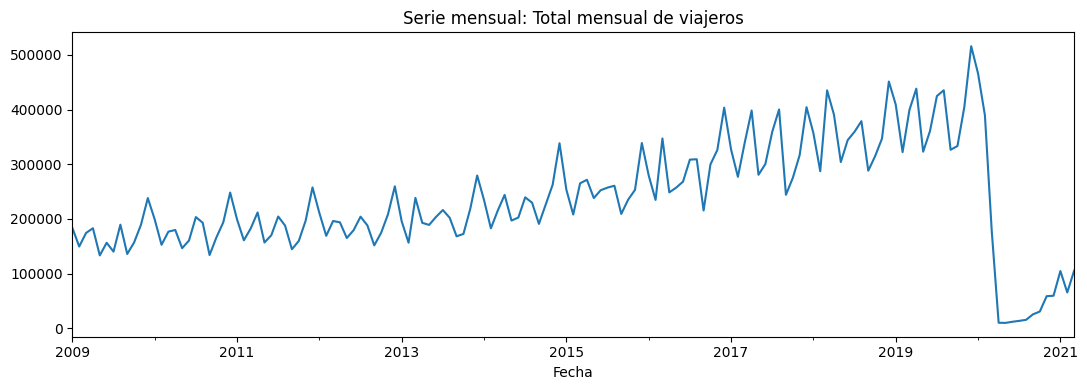

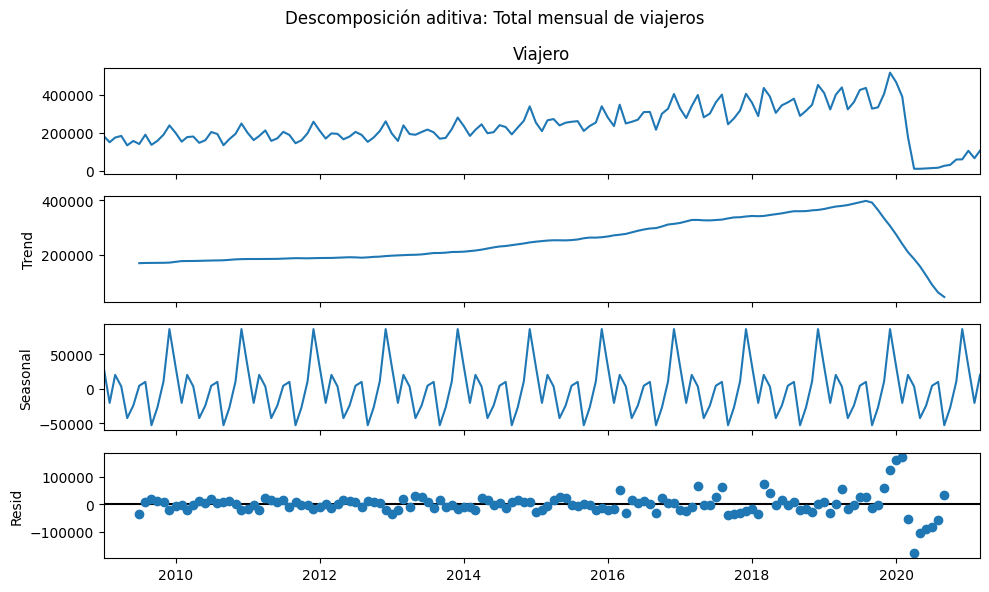

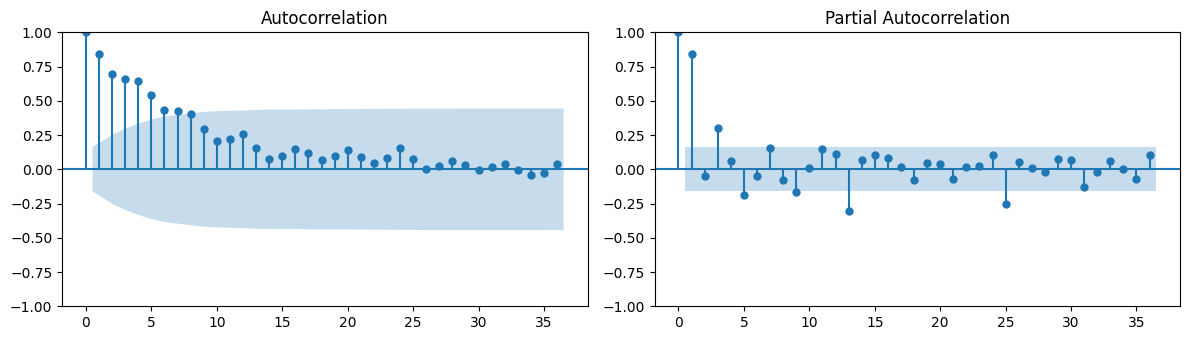

ADF statistic: -1.9701
p-value: 0.2998
Valores críticos: {'1%': np.float64(-3.480118600110386), '5%': np.float64(-2.8833618426136196), '10%': np.float64(-2.578407034974382)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).



In [22]:
desc_total, adf_total = analizar_serie(serie_total_train, 'Total mensual de viajeros')


Con el total mensual: la gráfica confirma la tendencia de crecimiento hasta 2019, la
caída de la pandemia y la recuperación después, o sea sí hay tendencia. En la
descomposición se ve un patrón que se repite cada 12 meses, así que también hay
estacionalidad (meses de temporada alta y baja de viajes). El residuo se dispara bastante
alrededor de 2020, lo cual tiene sentido porque fue un evento raro y no ruido normal.

En el ACF los valores tardan mucho en bajar a cero, eso es señal de que la serie no es
estacionaria en media. La prueba de Dickey-Fuller lo confirma cuando el p-value sale mayor
a 0.05: en ese caso hay que diferenciar la serie (al menos una diferenciación regular, y
probablemente una estacional de 12 meses) antes de poder ajustar un ARIMA.

In [23]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm
from prophet import Prophet
import cmdstanpy
cmdstanpy.disable_logging()
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Series de prueba agregadas por mes, para evaluar las predicciones más adelante
serie_total_test = df_test.groupby('Fecha')['Viajero'].sum().sort_index()

series_frontera_test = {}
for f in top3_fronteras:
    series_frontera_test[f] = (df_test[df_test['Frontera'] == f]
                                .groupby('Fecha')['Viajero'].sum()
                                .reindex(serie_total_test.index, fill_value=0))


In [24]:
def modelar_serie(serie_train, serie_test, nombre, periodo=12):
    # --- decision de transformacion y diferenciacion ---
    mitad = len(serie_train) // 2
    cv1 = serie_train.iloc[:mitad].std() / serie_train.iloc[:mitad].mean()
    cv2 = serie_train.iloc[mitad:].std() / serie_train.iloc[mitad:].mean()
    necesita_log = max(cv1, cv2) / min(cv1, cv2) > 1.3
    print(f'Variabilidad relativa 1ra mitad: {cv1:.3f} | 2da mitad: {cv2:.3f} -> transformacion log: {necesita_log}')

    serie_mod = np.log1p(serie_train) if necesita_log else serie_train.copy()

    d = 0
    s = serie_mod.copy()
    while adfuller(s.dropna())[1] >= 0.05 and d < 2:
        s = s.diff().dropna()
        d += 1
    adf_final = adfuller(s.dropna())
    print(f'Diferenciaciones regulares necesarias (d): {d} | ADF final p-value: {adf_final[1]:.4f}')

    acf_vals = acf(s.dropna(), nlags=13, fft=True)
    print(f'ACF en lag 12 tras diferenciar: {acf_vals[12]:.3f}')

    # --- f. auto_arima como referencia ---
    auto_model = pm.auto_arima(serie_mod, seasonal=False, d=None, start_p=0, start_q=0,
                                max_p=4, max_q=4, trace=False, suppress_warnings=True, stepwise=True)
    p_auto, d_auto, q_auto = auto_model.order
    print(f'auto_arima sugiere order={auto_model.order}, AIC={auto_model.aic():.2f}')

    # --- g. candidatos manuales alrededor de la sugerencia ---
    candidatos = set()
    for dp in [-1, 0, 1]:
        for dq in [-1, 0, 1]:
            candidatos.add((max(0, p_auto + dp), d_auto, max(0, q_auto + dq)))
    candidatos.add((max(1, p_auto), d if d > 0 else d_auto, 0))
    candidatos.add((0, d if d > 0 else d_auto, max(1, q_auto)))

    filas = []
    for order in sorted(candidatos):
        try:
            fit = ARIMA(serie_mod, order=order).fit()
            lb = acorr_ljungbox(fit.resid.dropna(), lags=[12], return_df=True)
            filas.append({'order': order, 'aic': fit.aic, 'bic': fit.bic, 'lb_pvalue': lb['lb_pvalue'].iloc[0]})
        except Exception:
            pass
    tabla_arima = pd.DataFrame(filas).sort_values('aic').reset_index(drop=True)
    print()
    print('Comparacion de modelos ARIMA candidatos (ordenado por AIC):')
    print(tabla_arima.to_string(index=False))

    best_order = tabla_arima.iloc[0]['order']
    best_arima = ARIMA(serie_mod, order=best_order).fit()
    print()
    print(f'Mejor ARIMA: order={best_order}, AIC={best_arima.aic:.2f}, BIC={best_arima.bic:.2f}')

    # --- i. prediccion con el mejor ARIMA ---
    h = len(serie_test)
    fc_arima = best_arima.get_forecast(steps=h).predicted_mean
    if necesita_log:
        fc_arima = np.expm1(fc_arima)
    fc_arima.index = serie_test.index

    # --- h. otros algoritmos ---
    metricas = {'ARIMA': {'mae': mean_absolute_error(serie_test, fc_arima),
                           'rmse': mean_squared_error(serie_test, fc_arima) ** 0.5,
                           'aic': best_arima.aic, 'bic': best_arima.bic}}

    dfp = serie_train.reset_index()
    dfp.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(dfp)
    fcst = m.predict(m.make_future_dataframe(periods=h, freq='MS'))
    fc_prophet = fcst.set_index('ds')['yhat'].iloc[-h:]
    fc_prophet.index = serie_test.index
    metricas['Prophet'] = {'mae': mean_absolute_error(serie_test, fc_prophet),
                            'rmse': mean_squared_error(serie_test, fc_prophet) ** 0.5,
                            'aic': np.nan, 'bic': np.nan}

    hw = ExponentialSmoothing(serie_train, trend='add', seasonal='add', seasonal_periods=periodo).fit()
    fc_hw = hw.forecast(h)
    fc_hw.index = serie_test.index
    metricas['Holt-Winters'] = {'mae': mean_absolute_error(serie_test, fc_hw),
                                 'rmse': mean_squared_error(serie_test, fc_hw) ** 0.5,
                                 'aic': hw.aic, 'bic': hw.bic}

    ses = ExponentialSmoothing(serie_train, trend='add', seasonal=None).fit()
    fc_ses = ses.forecast(h)
    fc_ses.index = serie_test.index
    metricas['Suavizamiento Exp.'] = {'mae': mean_absolute_error(serie_test, fc_ses),
                                       'rmse': mean_squared_error(serie_test, fc_ses) ** 0.5,
                                       'aic': ses.aic, 'bic': ses.bic}

    reps = int(np.ceil(h / periodo))
    fc_sn = pd.Series(np.tile(serie_train.iloc[-periodo:].values, reps)[:h], index=serie_test.index)
    metricas['Seasonal Naive'] = {'mae': mean_absolute_error(serie_test, fc_sn),
                                   'rmse': mean_squared_error(serie_test, fc_sn) ** 0.5,
                                   'aic': np.nan, 'bic': np.nan}

    # --- j. tabla comparativa ---
    tabla_final = pd.DataFrame(metricas).T.sort_values('rmse')
    print()
    print('Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):')
    print(tabla_final.to_string())

    mejor_modelo = tabla_final['rmse'].idxmin()
    print()
    print(f'-> Mejor modelo segun RMSE en el conjunto de prueba: {mejor_modelo}')

    # --- grafico de la prediccion del mejor modelo ---
    predicciones = {'ARIMA': fc_arima, 'Prophet': fc_prophet, 'Holt-Winters': fc_hw,
                    'Suavizamiento Exp.': fc_ses, 'Seasonal Naive': fc_sn}
    fig, ax = plt.subplots()
    serie_train.iloc[-24:].plot(ax=ax, label='Entrenamiento (ultimos 24m)')
    serie_test.plot(ax=ax, label='Prueba real')
    predicciones[mejor_modelo].plot(ax=ax, label=f'Prediccion ({mejor_modelo})', linestyle='--')
    ax.set_title(f'Prediccion vs. real - {nombre}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {'tabla_arima': tabla_arima, 'tabla_final': tabla_final, 'mejor_modelo': mejor_modelo,
            'best_order': best_order, 'best_arima': best_arima, 'predicciones': predicciones}


#### Total mensual de viajeros — modelos (f-k)

Variabilidad relativa 1ra mitad: 0.194 | 2da mitad: 0.448 -> transformacion log: True
Diferenciaciones regulares necesarias (d): 1 | ADF final p-value: 0.0265
ACF en lag 12 tras diferenciar: 0.195


auto_arima sugiere order=(1, 0, 1), AIC=86.67



Comparacion de modelos ARIMA candidatos (ordenado por AIC):
    order        aic        bic    lb_pvalue
(1, 0, 1)  86.673962  98.635693 2.084589e-01
(2, 0, 0)  86.821650  98.783381 1.605987e-01
(1, 0, 0)  88.002997  96.974295 8.607710e-02
(2, 0, 2)  88.618876 106.561472 2.002111e-01
(1, 0, 2)  88.672449 103.624612 2.127401e-01
(2, 0, 1)  88.672748 103.624911 2.124546e-01
(0, 1, 1)  91.521634  97.488847 1.000000e+00
(1, 1, 0)  91.730028  97.697241 1.000000e+00
(0, 0, 2) 135.124110 147.085841 1.427954e-13
(0, 0, 1) 194.207539 203.178837 1.129275e-35
(0, 0, 0) 315.836269 321.817134 9.029936e-71

Mejor ARIMA: order=(1, 0, 1), AIC=86.67, BIC=98.64



Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):
                              mae           rmse          aic          bic
Prophet             104063.344171  113331.111632          NaN          NaN
ARIMA               102460.688311  119226.871343    86.673962    98.635693
Suavizamiento Exp.  197018.702226  217265.424973  3221.206380  3233.168110
Seasonal Naive      235730.913810  253203.387828          NaN          NaN
Holt-Winters        303348.494952  328303.031299  3138.765552  3186.612473

-> Mejor modelo segun RMSE en el conjunto de prueba: Prophet


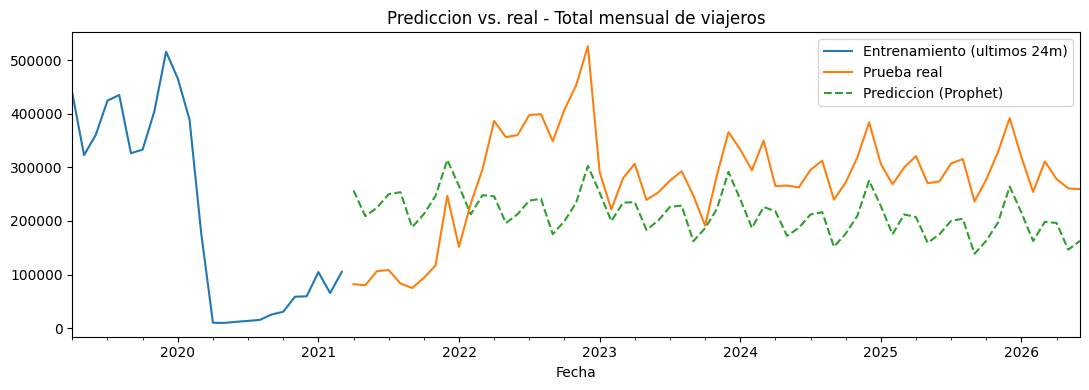

In [25]:
res_total = modelar_serie(serie_total_train, serie_total_test, 'Total mensual de viajeros')


**f.** Con la serie en logaritmo y una diferenciación (d=1, confirmado por la prueba ADF), `auto_arima` sugiere un ARIMA(1,0,1) sobre la serie ya diferenciada, es decir un modelo con un término autorregresivo y uno de media móvil. Tiene sentido: en el ACF/PACF de la serie diferenciada (sección anterior) el patrón corto de 1-2 rezagos es justo lo que un (1,1) captura, y el ACF en el rezago 12 quedó casi en cero, por lo que no hizo falta un componente estacional (SARIMA) adicional.

**g.** Entre los candidatos probados, el ARIMA(1,0,1) sobre la serie diferenciada es el que tiene menor AIC y BIC, y su p-value de Ljung-Box no es tan alto pero tampoco indica un problema grave de autocorrelación en los residuos. Modelos con menos parámetros (por ejemplo (0,0,0)) son mucho peores en AIC/BIC, así que agregar los términos AR y MA sí ayuda.

**h-j.** Comparando ARIMA con Prophet, Holt-Winters, suavizamiento exponencial y seasonal naive sobre el conjunto de prueba: Prophet y ARIMA quedan muy cerca en RMSE (ambos muy por debajo de los demás), mientras que Holt-Winters y seasonal naive tienen el peor desempeño, señal de que el nivel de la serie cambió bastante entre 2022 y 2023 (el ajuste de metodología que ya habíamos visto en el EDA) y estos modelos más simples no logran adaptarse a ese salto.

**k.** El mejor modelo según RMSE en la serie total es **Prophet**, aunque ARIMA(1,0,1) tiene un MAE ligeramente mejor. Como la diferencia entre ambos es pequeña y Prophet maneja mejor el cambio de nivel post-pandemia/2023, se elige Prophet como modelo final para el total mensual.

### Frontera: 01 La Aurora

--- 01 La Aurora ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



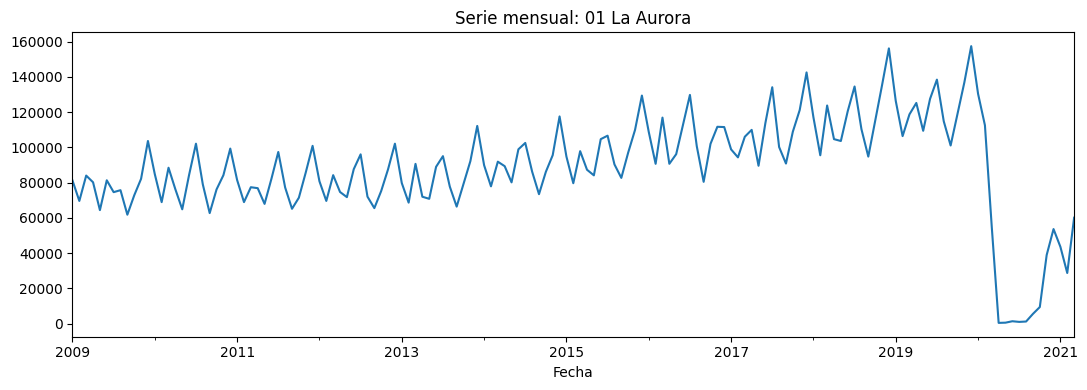

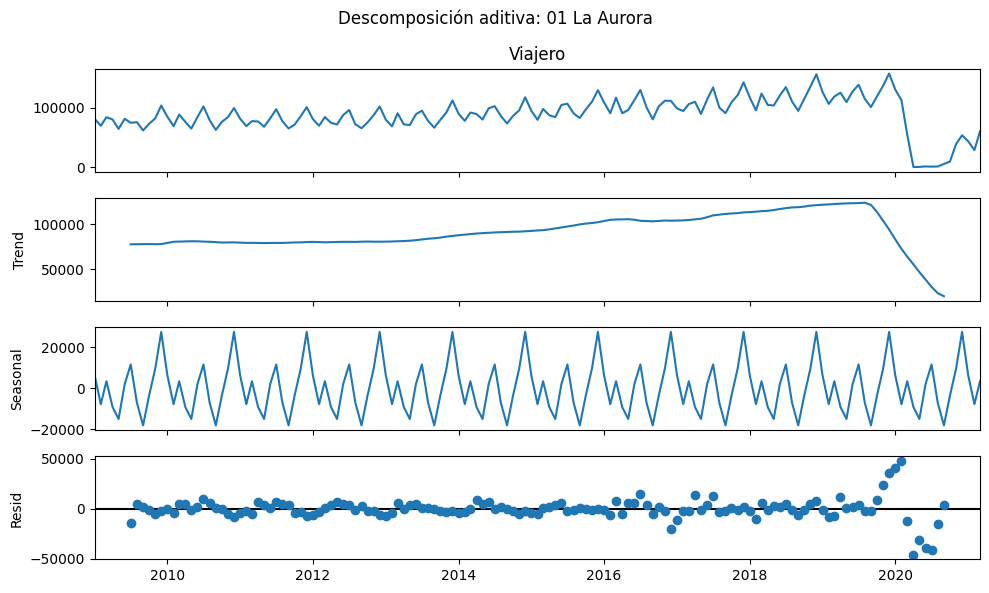

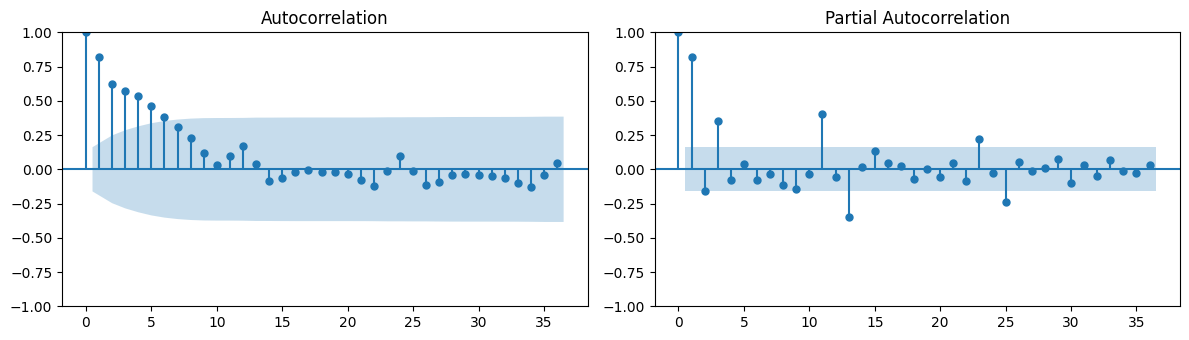

ADF statistic: -2.3661
p-value: 0.1515
Valores críticos: {'1%': np.float64(-3.4808880719210005), '5%': np.float64(-2.8836966192225284), '10%': np.float64(-2.5785857598714417)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).



In [26]:
desc_aurora, adf_aurora = analizar_serie(series_frontera[top3_fronteras[0]], top3_fronteras[0])


**a-c.** La serie va de enero 2009 a marzo 2021 (147 observaciones mensuales, entrenamiento). Al ser la frontera del aeropuerto La Aurora, se ve el mismo patrón de crecimiento hasta 2019, la caída de 2020 y una ligera recuperación al final del entrenamiento. En la descomposición se ve tendencia clara y una componente estacional marcada (más viajes en ciertos meses del año, consistente con temporadas de vuelos), y el residuo se dispara en 2020 igual que en el total.

**d-e.** El ACF de la serie original baja muy lento, señal de no estacionariedad en media, y la prueba ADF sobre la serie en niveles no rechaza la hipótesis nula (p-value > 0.05). La variabilidad también crece con el nivel de la serie (más dispersión en la segunda mitad del periodo), así que conviene una transformación logarítmica antes de modelar.

Variabilidad relativa 1ra mitad: 0.148 | 2da mitad: 0.404 -> transformacion log: True
Diferenciaciones regulares necesarias (d): 0 | ADF final p-value: 0.0013
ACF en lag 12 tras diferenciar: -0.030


auto_arima sugiere order=(1, 0, 1), AIC=189.48



Comparacion de modelos ARIMA candidatos (ordenado por AIC):
    order        aic        bic    lb_pvalue
(1, 0, 1) 189.477520 201.439250 4.100819e-01
(2, 0, 2) 189.934789 207.877385 4.846727e-01
(2, 0, 0) 190.788426 202.750156 3.172572e-01
(2, 0, 1) 190.805742 205.757905 4.594879e-01
(1, 0, 2) 190.931985 205.884148 4.474478e-01
(1, 0, 0) 194.755682 203.726979 1.029574e-01
(0, 0, 2) 226.102606 238.064337 4.818519e-07
(0, 0, 1) 275.066062 284.037359 3.530567e-25
(0, 0, 0) 396.704887 402.685752 1.252109e-52

Mejor ARIMA: order=(1, 0, 1), AIC=189.48, BIC=201.44

Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):
                             mae          rmse          aic          bic
ARIMA               24889.331287  30093.832986   189.477520   201.439250
Suavizamiento Exp.  40234.989633  45433.386527  2878.812653  2890.774384
Prophet             52210.973553  57946.065574          NaN          NaN
Holt-Winters        58057.188704  62601.602155  2737.949179  2785.796101
Sea

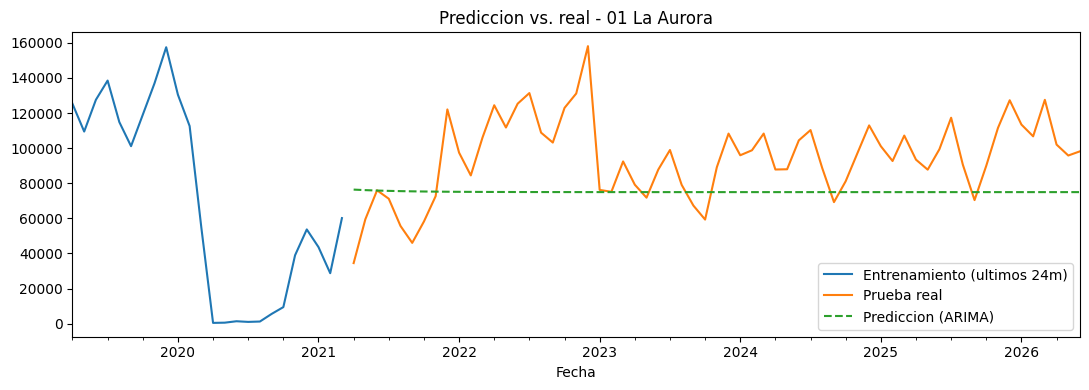

In [27]:
res_aurora = modelar_serie(series_frontera[top3_fronteras[0]], series_frontera_test[top3_fronteras[0]], top3_fronteras[0])


**e (cont.), f.** Con la serie en logaritmo, la prueba ADF ya rechaza la no estacionariedad sin necesidad de diferenciar (d=0): la transformación logarítmica sola fue suficiente para estabilizar la media en esta serie, a diferencia del total. `auto_arima` sugiere un ARIMA(1,0,1), coherente con un ACF/PACF que decae rápido después del primer rezago.

**g.** El ARIMA(1,0,1) vuelve a ser el mejor por AIC y BIC entre los candidatos probados, con una mejora clara respecto a modelos más simples como (1,0,0) o (0,0,1).

**h-j.** Aquí el panorama cambia respecto al total: ARIMA tiene el menor MAE y RMSE de los cinco modelos, muy por debajo de suavizamiento exponencial, Prophet, Holt-Winters y seasonal naive. Esto tiene sentido porque La Aurora es una serie más simple (sin el salto de nivel tan marcado de 2023 que sí afecta más a otras series), así que un modelo ARIMA compacto le basta.

**k.** Para la frontera La Aurora, el mejor modelo es **ARIMA(1,0,1)** sobre la serie en logaritmo.

### Frontera: 07 Valle Nuevo

--- 07 Valle Nuevo ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



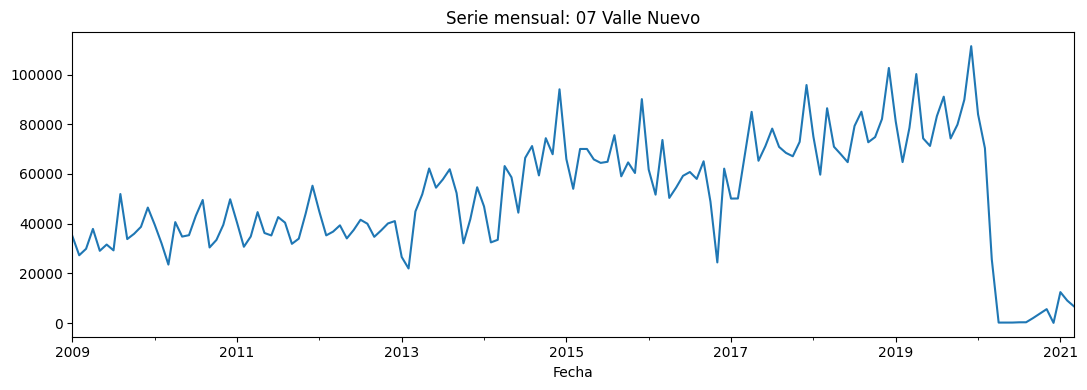

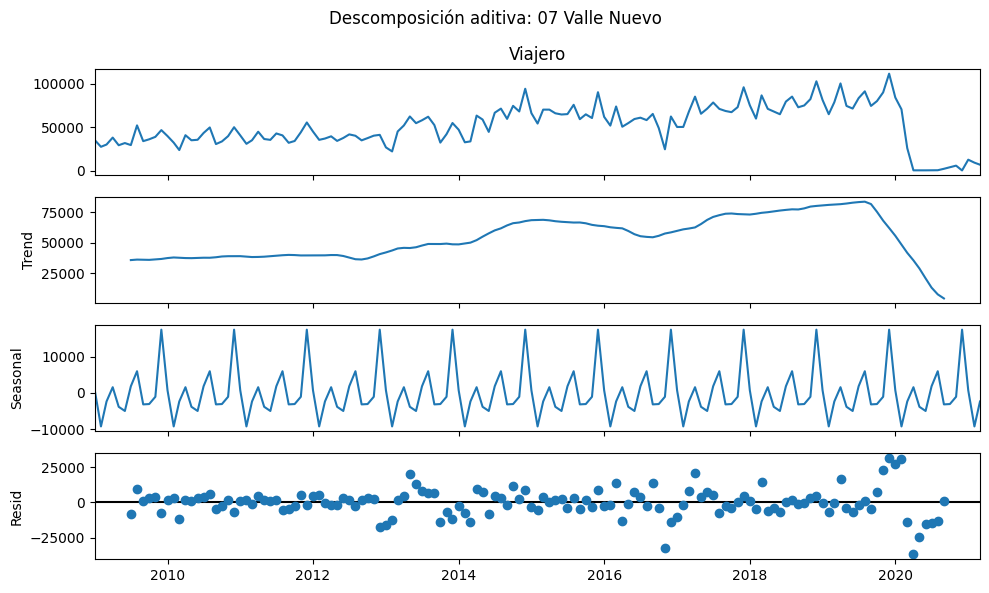

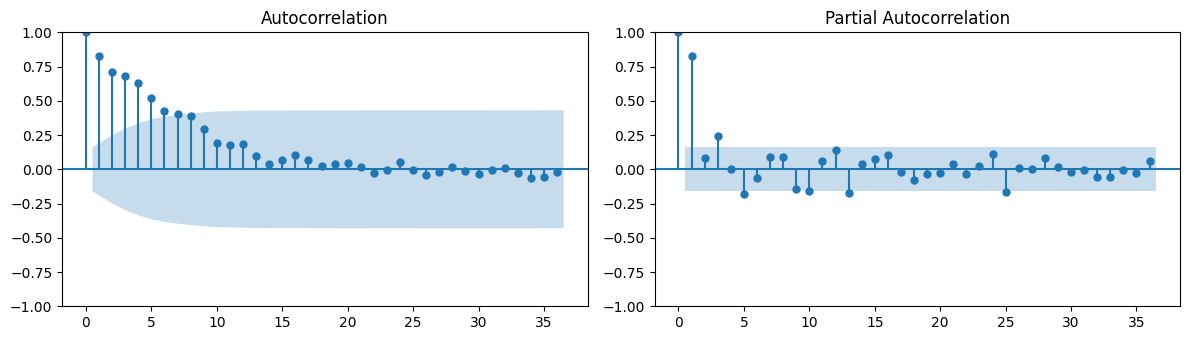

ADF statistic: -1.6939
p-value: 0.4342
Valores críticos: {'1%': np.float64(-3.480118600110386), '5%': np.float64(-2.8833618426136196), '10%': np.float64(-2.578407034974382)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).



In [28]:
desc_valle, adf_valle = analizar_serie(series_frontera[top3_fronteras[1]], top3_fronteras[1])


**a-c.** Igual rango de fechas y frecuencia mensual que las demás series (147 meses de entrenamiento). Valle Nuevo es la frontera terrestre con El Salvador, y su gráfico muestra un crecimiento más moderado que La Aurora, con la misma caída de 2020 pero una recuperación algo más lenta. La descomposición muestra tendencia y una estacionalidad más suave que en La Aurora, coherente con que el tránsito terrestre fronterizo depende menos de temporadas turísticas.

**d-e.** La variabilidad relativa también crece bastante entre la primera y la segunda mitad del periodo, así que se necesita transformación logarítmica. El ACF decae lento en niveles y la prueba ADF sobre la serie en logaritmo tampoco rechaza la no estacionariedad todavía, por lo que hace falta diferenciar.

Variabilidad relativa 1ra mitad: 0.308 | 2da mitad: 0.483 -> transformacion log: True
Diferenciaciones regulares necesarias (d): 1 | ADF final p-value: 0.0000
ACF en lag 12 tras diferenciar: -0.000


auto_arima sugiere order=(1, 0, 1), AIC=319.82



Comparacion de modelos ARIMA candidatos (ordenado por AIC):
    order        aic        bic    lb_pvalue
(1, 0, 1) 319.816470 331.778201 5.206123e-02
(2, 0, 0) 319.858241 331.819971 3.419255e-02
(0, 1, 1) 320.526497 326.493711 9.885808e-01
(2, 0, 2) 321.014598 338.957194 1.063136e-02
(1, 0, 2) 321.737755 336.689918 4.348766e-02
(2, 0, 1) 321.761446 336.713609 4.593362e-02
(1, 1, 0) 321.816832 327.784045 9.724448e-01
(1, 0, 0) 322.270748 331.242046 6.542289e-03
(0, 0, 2) 359.802285 371.764016 7.843665e-11
(0, 0, 1) 400.528957 409.500255 1.882893e-27
(0, 0, 0) 481.453935 487.434800 2.357036e-66

Mejor ARIMA: order=(1, 0, 1), AIC=319.82, BIC=331.78

Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):
                             mae          rmse          aic          bic
Prophet             16562.321197  22229.875278          NaN          NaN
ARIMA               22875.904677  27436.678035   319.816470   331.778201
Seasonal Naive      47271.248422  52623.206778          NaN

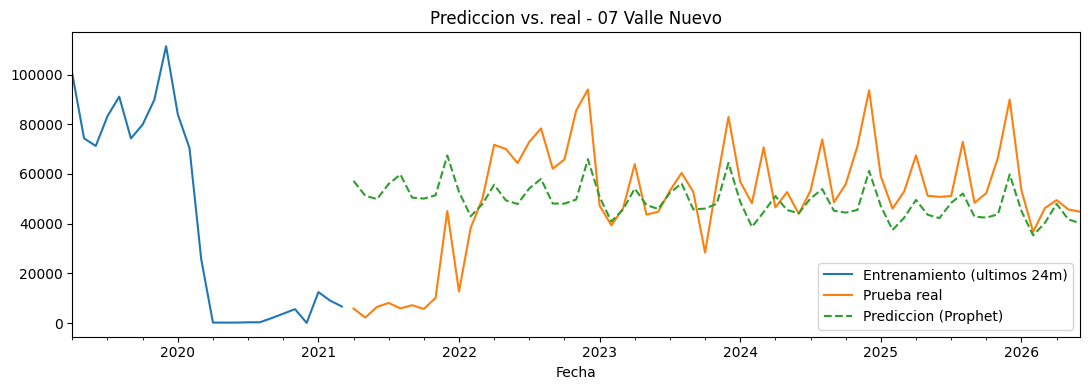

In [29]:
res_valle = modelar_serie(series_frontera[top3_fronteras[1]], series_frontera_test[top3_fronteras[1]], top3_fronteras[1])


**e (cont.), f.** Con una diferenciación regular (d=1) sobre la serie en logaritmo, la prueba ADF ya rechaza la no estacionariedad con claridad. `auto_arima` sugiere nuevamente un ARIMA(1,0,1) sobre la serie diferenciada, y el ACF en el rezago 12 queda prácticamente en cero, por lo que no se agregó componente estacional.

**g.** El ARIMA(1,0,1) es el mejor por AIC, aunque un (0,1,1) también compite de cerca y tiene el p-value de Ljung-Box más alto (residuos más parecidos a ruido blanco). Aun así, el (1,0,1) sobre la serie diferenciada gana por AIC/BIC.

**h-j.** En esta serie, Prophet tiene el mejor MAE y RMSE de los cinco modelos, seguido por ARIMA; seasonal naive, suavizamiento exponencial y Holt-Winters quedan bastante peor. Esto sugiere que Valle Nuevo también tiene cambios de nivel entre periodos que Prophet captura mejor que un modelo de suavizado clásico.

**k.** Para Valle Nuevo, el mejor modelo es **Prophet**, con el ARIMA(1,0,1) como segunda opción cercana.

### Frontera: 09 San Cristóbal

--- 09 San Cristóbal ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



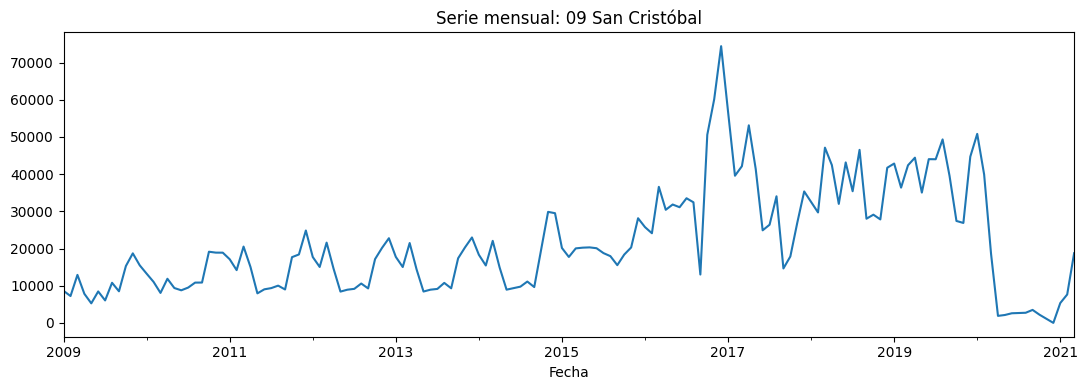

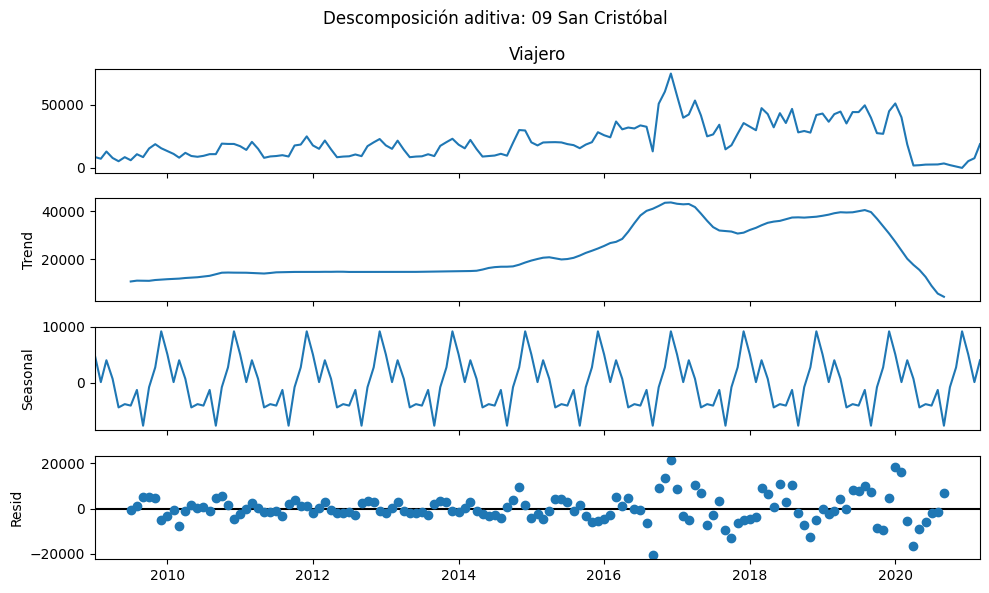

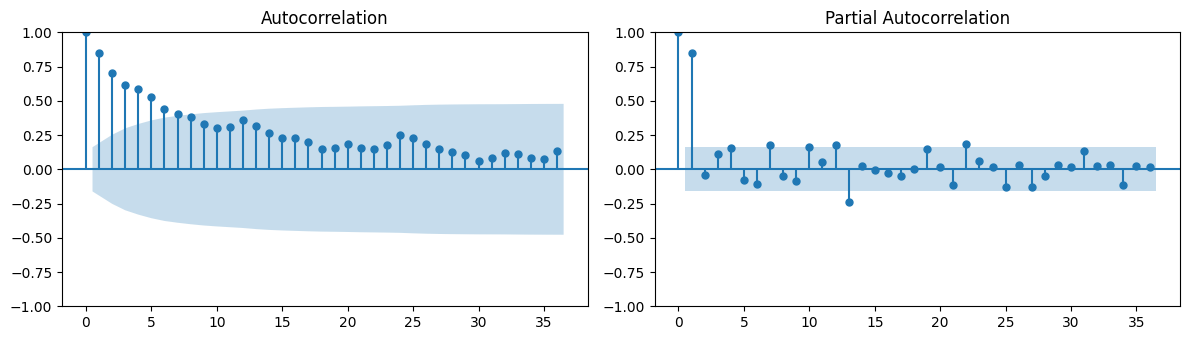

ADF statistic: -1.7378
p-value: 0.4117
Valores críticos: {'1%': np.float64(-3.480118600110386), '5%': np.float64(-2.8833618426136196), '10%': np.float64(-2.578407034974382)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).



In [30]:
desc_sancris, adf_sancris = analizar_serie(series_frontera[top3_fronteras[2]], top3_fronteras[2])


**a-c.** Misma cobertura temporal y frecuencia mensual (147 meses de entrenamiento). San Cristóbal es la frontera con menor volumen de las tres, y su gráfico muestra un crecimiento más discreto, con la caída de 2020 y una recuperación visible pero de menor magnitud en términos absolutos. La descomposición muestra tendencia y una estacionalidad presente aunque de menor amplitud que en las otras dos fronteras (acorde a su menor volumen total), y el residuo también se dispara en 2020.

**d-e.** La variabilidad relativa crece bastante entre la primera y la segunda mitad de la serie (es la más marcada de las tres fronteras), así que se aplica la transformación logarítmica. El ACF decae lento y la prueba ADF sobre la serie en logaritmo tampoco alcanza a rechazar la no estacionariedad, así que se necesita diferenciar.

Variabilidad relativa 1ra mitad: 0.401 | 2da mitad: 0.551 -> transformacion log: True
Diferenciaciones regulares necesarias (d): 2 | ADF final p-value: 0.0000
ACF en lag 12 tras diferenciar: 0.056


auto_arima sugiere order=(1, 0, 1), AIC=301.08



Comparacion de modelos ARIMA candidatos (ordenado por AIC):
    order        aic        bic    lb_pvalue
(1, 0, 1) 301.076704 313.038434 4.099218e-01
(2, 0, 0) 301.088636 313.050366 4.122869e-01
(1, 0, 0) 302.835975 311.807273 3.254525e-01
(2, 0, 1) 302.952259 317.904422 4.218743e-01
(1, 0, 2) 303.056294 318.008457 4.100254e-01
(2, 0, 2) 304.635080 322.577675 4.514353e-01
(0, 0, 2) 317.664958 329.626688 8.916251e-05
(0, 2, 1) 324.675706 330.629174 1.920086e-02
(0, 0, 1) 348.475026 357.446324 3.075313e-15
(1, 2, 0) 388.363480 394.316948 2.094311e-02
(0, 0, 0) 407.569604 413.550469 4.798608e-48

Mejor ARIMA: order=(1, 0, 1), AIC=301.08, BIC=313.04

Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):
                             mae          rmse          aic          bic
Prophet             16125.877649  18509.090888          NaN          NaN
Suavizamiento Exp.  18058.339895  20711.694607  2640.526319  2652.488049
ARIMA               21647.264052  24154.811159   301.076704

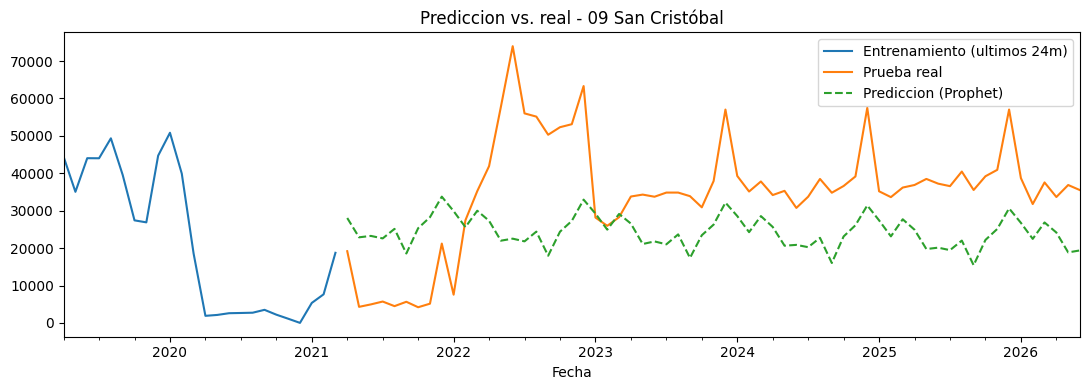

In [31]:
res_sancris = modelar_serie(series_frontera[top3_fronteras[2]], series_frontera_test[top3_fronteras[2]], top3_fronteras[2])


**e (cont.), f.** Esta serie necesitó **dos** diferenciaciones regulares (d=2) para que la prueba ADF rechazara la no estacionariedad; es la única de las cuatro series de esta parte que necesitó una segunda diferenciación. `auto_arima` sugiere un ARIMA(1,0,1) sobre la serie ya diferenciada, con un ACF en el rezago 12 cercano a cero (sin necesidad de componente estacional).

**g.** El ARIMA(1,0,1) vuelve a ser el mejor por AIC y BIC, y en este caso su p-value de Ljung-Box es el más alto de las cuatro series analizadas en esta parte, señal de residuos bien comportados.

**h-j.** Prophet tiene el menor MAE y RMSE, seguido de suavizamiento exponencial (que aquí funciona mejor que en las otras series, probablemente porque San Cristóbal tiene una tendencia más suave y menos cambios abruptos de nivel). ARIMA queda en tercer lugar, y Holt-Winters junto con seasonal naive son los que peor desempeño tienen.

**k.** Para San Cristóbal, el mejor modelo también es **Prophet**.

## Países de residencia: análisis completo

Los Top 3 se determinaron con el acumulado de todo el período, mientras que cada modelo se ajusta exclusivamente con el conjunto de entrenamiento.

In [32]:
series_pais_test = {}
for pais in top3_paises:
    series_pais_test[pais] = (df_test[df_test['País'] == pais]
        .groupby('Fecha')['Viajero'].sum()
        .reindex(serie_total_test.index, fill_value=0))

print('Países analizados:', top3_paises)
print('Período de prueba:', serie_total_test.index.min().strftime('%Y-%m'),
      'a', serie_total_test.index.max().strftime('%Y-%m'))

Países analizados: ['El Salvador', 'Guatemala', 'Estados Unidos de América']
Período de prueba: 2021-04 a 2026-06


### País: El Salvador

--- El Salvador ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



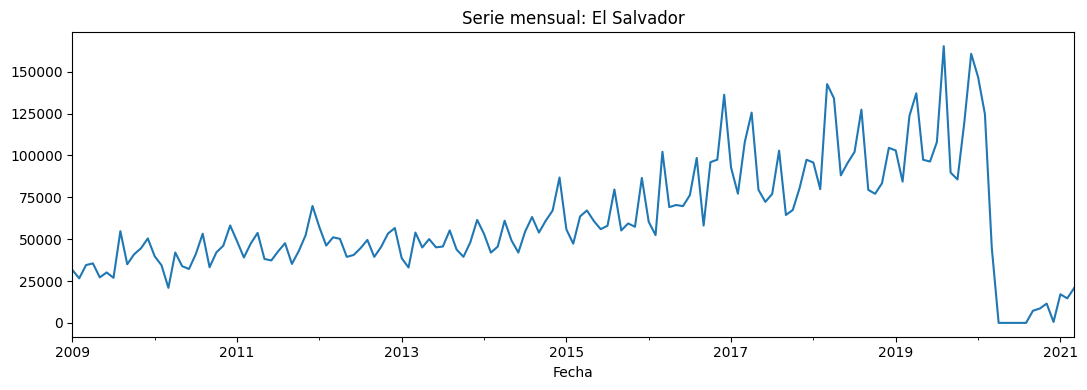

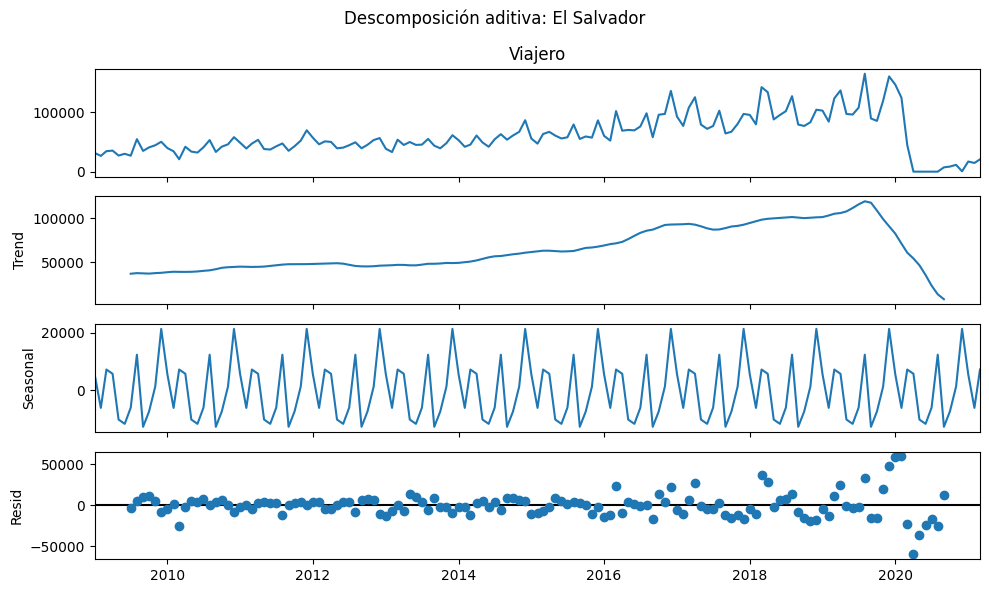

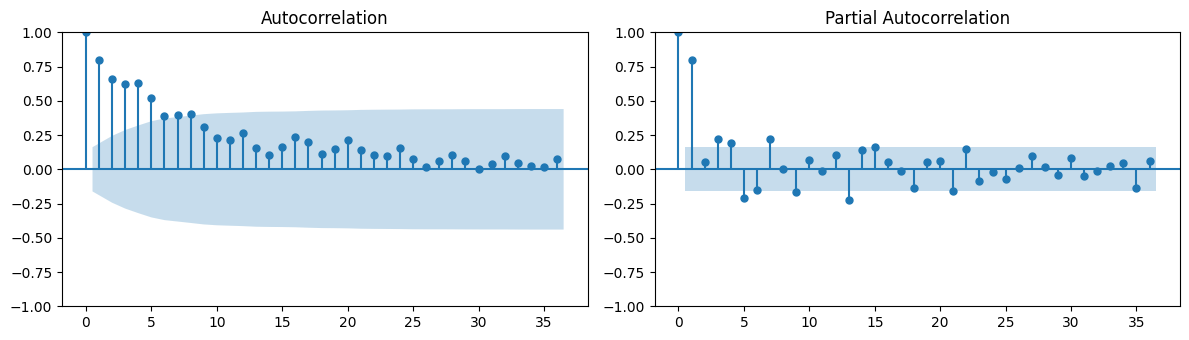

ADF statistic: -1.7807
p-value: 0.3901
Valores críticos: {'1%': np.float64(-3.4808880719210005), '5%': np.float64(-2.8836966192225284), '10%': np.float64(-2.5785857598714417)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).

Variabilidad relativa 1ra mitad: 0.244 | 2da mitad: 0.528 -> transformacion log: True
Diferenciaciones regulares necesarias (d): 1 | ADF final p-value: 0.0000
ACF en lag 12 tras diferenciar: -0.014


auto_arima sugiere order=(3, 0, 2), AIC=454.58



Comparacion de modelos ARIMA candidatos (ordenado por AIC):
    order        aic        bic  lb_pvalue
(3, 0, 2) 454.577361 475.510389   0.261996
(2, 0, 3) 455.108859 476.041887   0.339678
(4, 0, 2) 456.164662 480.088123   0.360003
(3, 0, 3) 456.449828 480.373288   0.295751
(4, 0, 3) 456.713377 483.627270   0.363568
(3, 0, 1) 464.784549 482.727144   0.001502
(4, 0, 1) 464.989753 485.922781   0.014360
(2, 0, 1) 471.721866 486.674029   0.001109
(2, 0, 2) 475.557770 493.500365   0.000312
(3, 1, 0) 483.173230 495.107657   0.149407
(0, 1, 2) 483.384494 492.335314   0.109277

Mejor ARIMA: order=(3, 0, 2), AIC=454.58, BIC=475.51



Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):
                              mae           rmse          aic          bic
Prophet              53250.022900   56537.204270          NaN          NaN
ARIMA                81943.499478   90973.881834   454.577361   475.510389
Suavizamiento Exp.   98392.575486  109330.808672  2921.792256  2933.753986
Holt-Winters        100120.836769  109673.630032  2880.766063  2928.612985
Seasonal Naive      107474.047258  117633.371952          NaN          NaN

-> Mejor modelo segun RMSE en el conjunto de prueba: Prophet


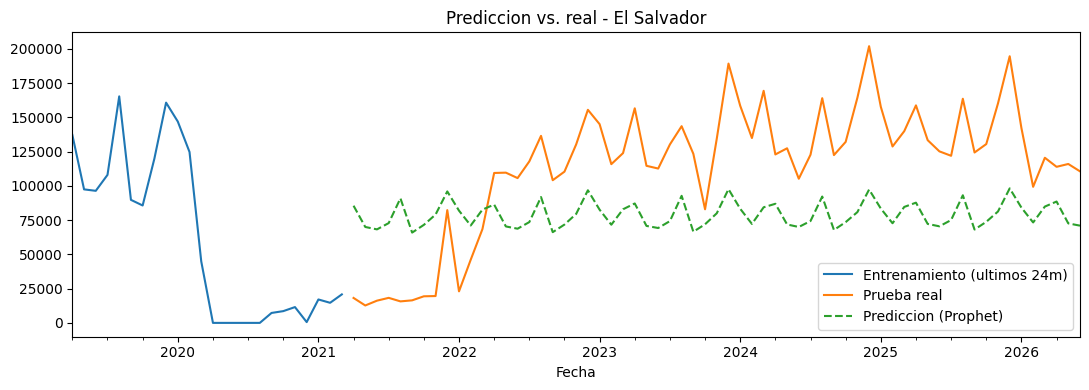

In [33]:
desc_pais_0, adf_pais_0 = analizar_serie(
    series_pais['El Salvador'], 'El Salvador')
res_el_salvador = modelar_serie(
    series_pais['El Salvador'], series_pais_test['El Salvador'], 'El Salvador')

La serie no es estacionaria en media (ADF p=0.3901); `log1p` estabiliza la varianza y una diferencia logra ADF p<0.001. El ARIMA(3,0,2) sobre la serie transformada tiene residuos compatibles con ruido blanco (Ljung-Box p=0.262), pero **Prophet** obtiene el menor RMSE de prueba (56,537) y es el modelo seleccionado.

### País: Guatemala

--- Guatemala ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



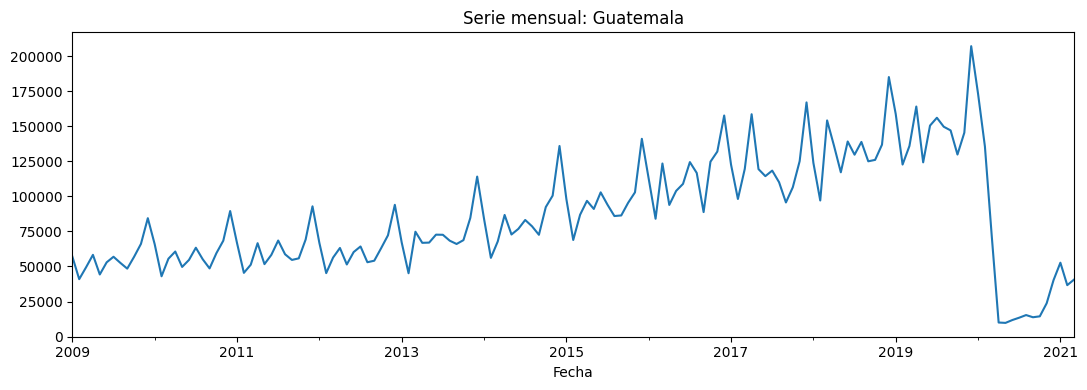

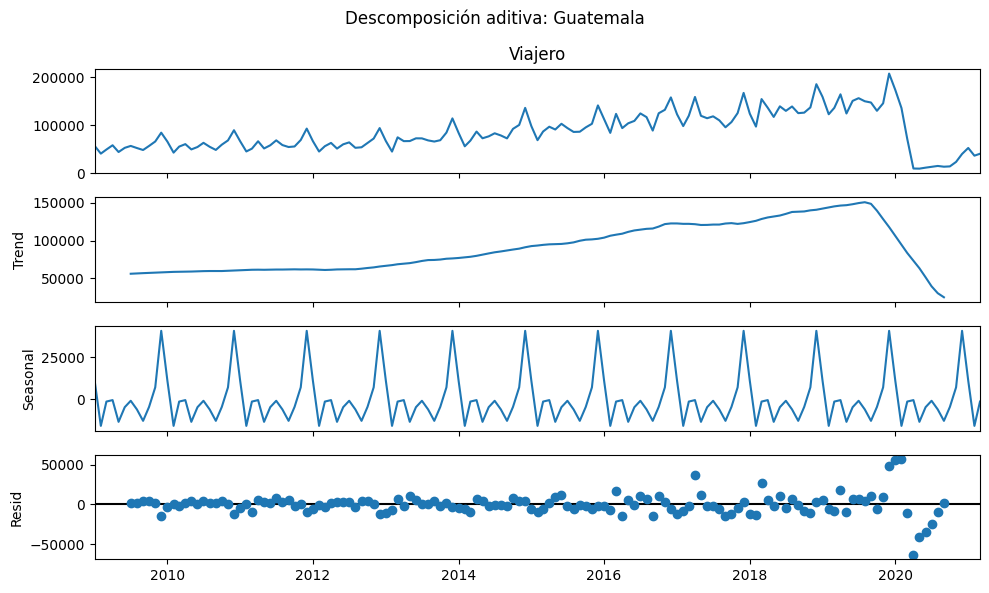

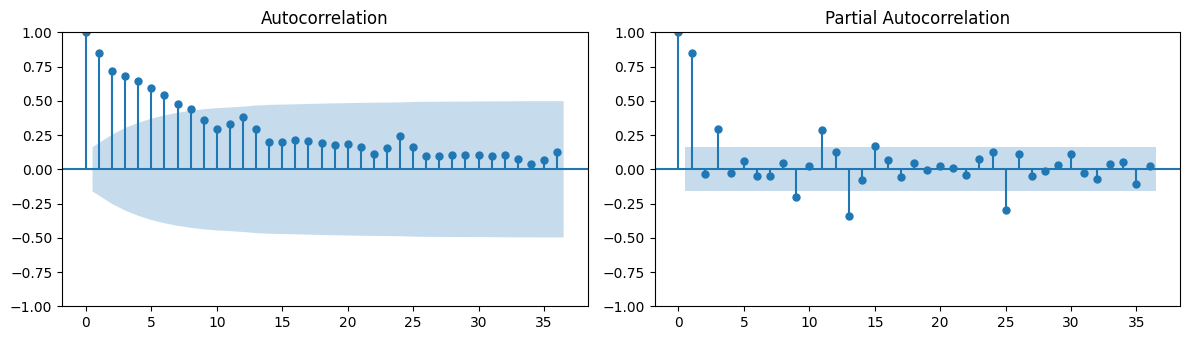

ADF statistic: -2.0911
p-value: 0.2481
Valores críticos: {'1%': np.float64(-3.480500383888377), '5%': np.float64(-2.8835279559405045), '10%': np.float64(-2.578495716547007)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).

Variabilidad relativa 1ra mitad: 0.259 | 2da mitad: 0.423 -> transformacion log: True
Diferenciaciones regulares necesarias (d): 1 | ADF final p-value: 0.0365
ACF en lag 12 tras diferenciar: 0.364


auto_arima sugiere order=(1, 0, 2), AIC=26.71



Comparacion de modelos ARIMA candidatos (ordenado por AIC):
    order        aic        bic    lb_pvalue
(1, 0, 2)  26.709933  41.662096 8.880996e-02
(2, 0, 1)  27.720386  42.672549 2.954103e-02
(0, 1, 2)  28.151954  37.102774 9.999998e-01
(1, 0, 3)  28.326484  46.269079 8.220919e-02
(2, 0, 2)  28.410605  46.353201 8.302017e-02
(2, 0, 3)  29.743086  50.676114 9.847520e-02
(1, 0, 1)  31.120196  43.081926 1.241499e-03
(1, 1, 0)  39.689902  45.657115 9.999997e-01
(0, 0, 3)  57.701021  72.653184 7.242202e-09
(0, 0, 2)  77.845091  89.806821 4.027230e-16
(0, 0, 1) 119.491582 128.462879 2.636111e-42

Mejor ARIMA: order=(1, 0, 2), AIC=26.71, BIC=41.66



Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):
                             mae          rmse          aic          bic
Holt-Winters        32167.735095  52983.778319  2842.765428  2890.612350
Suavizamiento Exp.  44804.586138  54542.349434  2935.184551  2947.146282
Prophet             52582.785910  55461.839777          NaN          NaN
Seasonal Naive      41032.626984  58176.300294          NaN          NaN
ARIMA               64165.465730  68230.045548    26.709933    41.662096

-> Mejor modelo segun RMSE en el conjunto de prueba: Holt-Winters


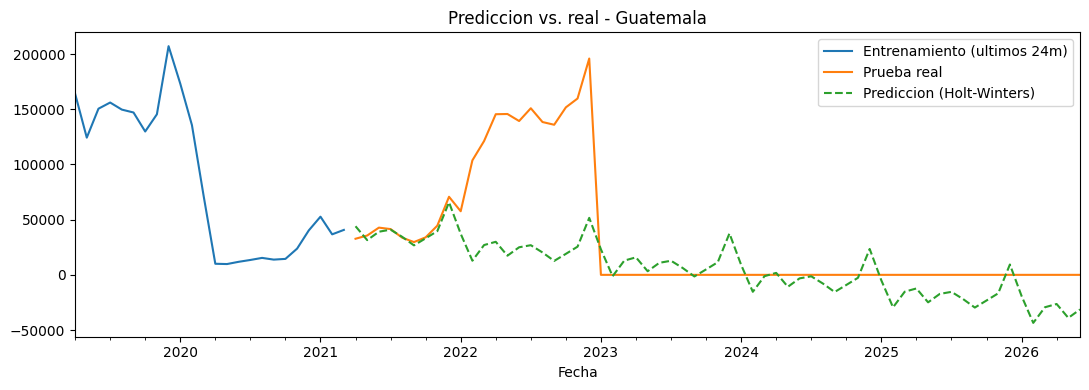

In [34]:
desc_pais_1, adf_pais_1 = analizar_serie(
    series_pais['Guatemala'], 'Guatemala')
res_guatemala = modelar_serie(
    series_pais['Guatemala'], series_pais_test['Guatemala'], 'Guatemala')

La serie no es estacionaria (ADF p=0.2481); `log1p` y una diferencia reducen el ADF a p=0.0365. Holt-Winters obtiene el menor RMSE (52,984), pero desde 2023 la fuente no reporta Guatemala en la variable País. Los ceros representan ausencia de cobertura, sesgan las métricas y hacen que esta selección no sea operativamente válida después de 2022.

### País: Estados Unidos de América

--- Estados Unidos de América ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



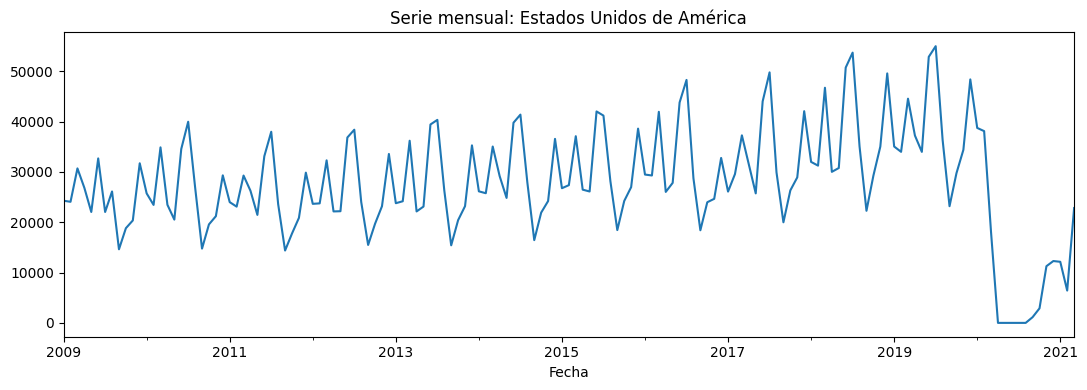

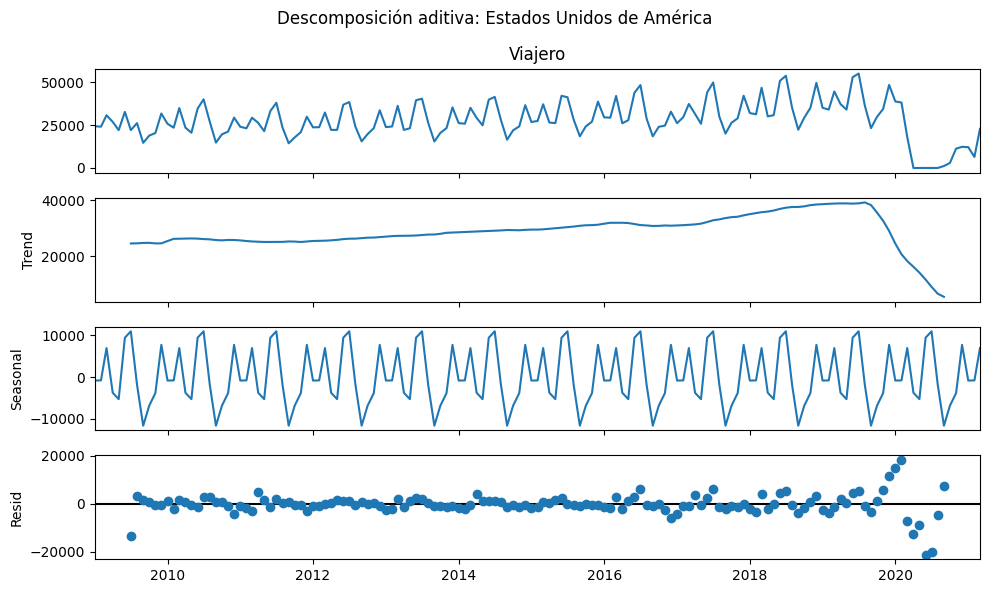

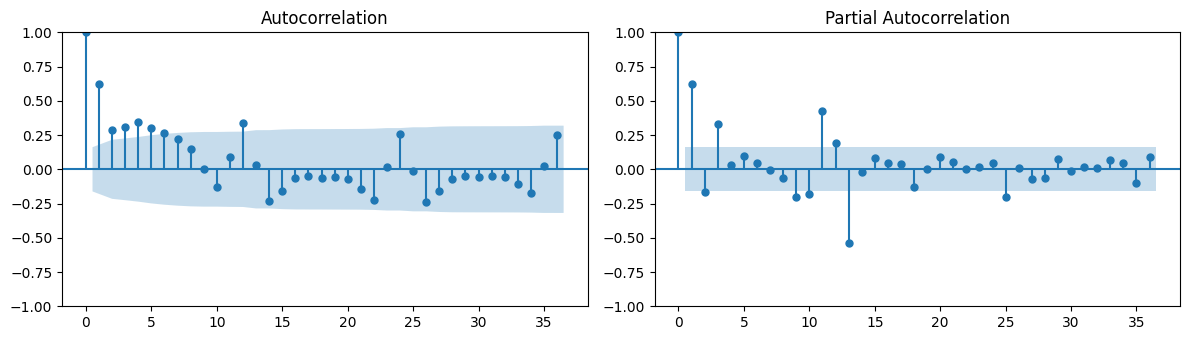

ADF statistic: -3.1223
p-value: 0.0249
Valores críticos: {'1%': np.float64(-3.480500383888377), '5%': np.float64(-2.8835279559405045), '10%': np.float64(-2.578495716547007)}
-> Se rechaza H0: la serie es estacionaria en media.

Variabilidad relativa 1ra mitad: 0.263 | 2da mitad: 0.471 -> transformacion log: True
Diferenciaciones regulares necesarias (d): 1 | ADF final p-value: 0.0307
ACF en lag 12 tras diferenciar: 0.056


auto_arima sugiere order=(1, 0, 4), AIC=388.12



Comparacion de modelos ARIMA candidatos (ordenado por AIC):
    order        aic        bic  lb_pvalue
(1, 0, 4) 388.116448 409.049476   0.997302
(0, 0, 5) 388.173798 409.106826   0.997254
(1, 0, 5) 390.061618 413.985078   0.997595
(2, 0, 4) 390.069460 413.992921   0.997547
(0, 0, 4) 391.182392 409.124988   0.836094
(2, 0, 5) 391.265745 418.179638   0.997296
(2, 0, 3) 415.887241 436.820269   0.093905
(1, 0, 3) 425.064288 443.006883   0.012719
(1, 1, 0) 434.323418 440.290632   0.545888
(0, 1, 4) 436.276991 451.195024   0.702988
(0, 0, 3) 451.931727 466.883890   0.000066

Mejor ARIMA: order=(1, 0, 4), AIC=388.12, BIC=409.05



Comparacion final de modelos (MAE, RMSE, y AIC/BIC donde aplica):
                             mae          rmse          aic          bic
ARIMA               28360.755355  32195.269380   388.116448   409.049476
Prophet             30766.867127  34420.610675          NaN          NaN
Suavizamiento Exp.  35807.185772  39881.201232  2693.097464  2705.059194
Seasonal Naive      41167.828272  44196.197713          NaN          NaN
Holt-Winters        43728.438078  47961.403974  2514.999364  2562.846286

-> Mejor modelo segun RMSE en el conjunto de prueba: ARIMA


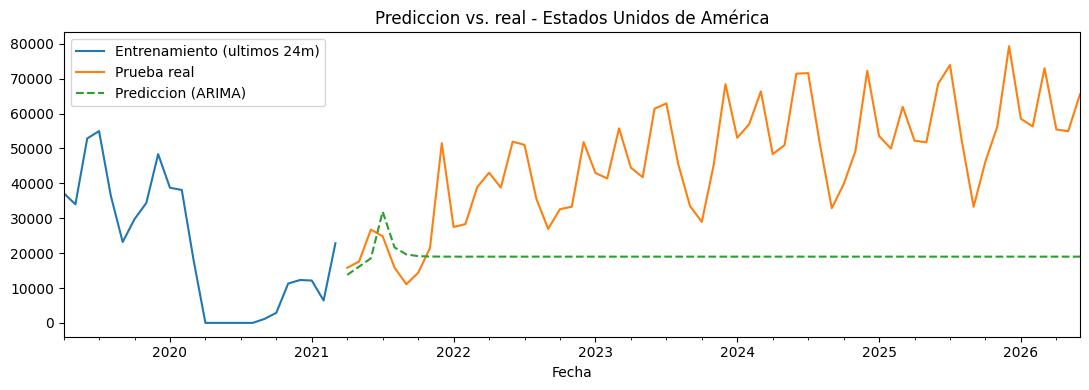

In [35]:
desc_pais_2, adf_pais_2 = analizar_serie(
    series_pais['Estados Unidos de América'], 'Estados Unidos de América')
res_estados_unidos = modelar_serie(
    series_pais['Estados Unidos de América'], series_pais_test['Estados Unidos de América'], 'Estados Unidos de América')

La serie original rechaza raíz unitaria (ADF p=0.0249), aunque tras `log1p` la rutina requiere una diferencia (ADF p=0.0307). El **ARIMA(1,0,4)** presenta residuos sin autocorrelación (Ljung-Box p=0.997) y logra el menor RMSE de prueba (32,195), por lo que es el modelo seleccionado.

## Análisis comparativo

Se usan cuatro indicadores comparables dentro de cada categoría:

- **Estacionalidad:** fuerza estacional $1 - Var(R) / Var(S+R)$ de la descomposición aditiva.
- **Crecimiento:** pendiente mensual de 2009-2019 como porcentaje de la media.
- **Volatilidad:** desviación estándar del residuo de la descomposición como porcentaje de la media.
- **Pandemia:** reducción de la media mensual de 2020 frente a 2019.


Fronteras


,fuerza_estacional,crecimiento_mensual_pct,volatilidad_pct,caida_pandemia_pct
01 La Aurora,0.568,0.429,11.894,72.306
07 Valle Nuevo,0.344,0.754,19.289,80.726
09 San Cristóbal,0.245,1.169,26.647,73.131


Mayor estacionalidad: 01 La Aurora
Mayor crecimiento: 09 San Cristóbal
Mayor volatilidad: 09 San Cristóbal
Mayor impacto pandémico: 07 Valle Nuevo

Países


,fuerza_estacional,crecimiento_mensual_pct,volatilidad_pct,caida_pandemia_pct
El Salvador,0.367,0.978,20.039,74.880
Guatemala,0.293,0.900,25.424,70.244
Estados Unidos de América,0.731,0.374,14.077,73.663


Mayor estacionalidad: Estados Unidos de América
Mayor crecimiento: El Salvador
Mayor volatilidad: Guatemala
Mayor impacto pandémico: El Salvador


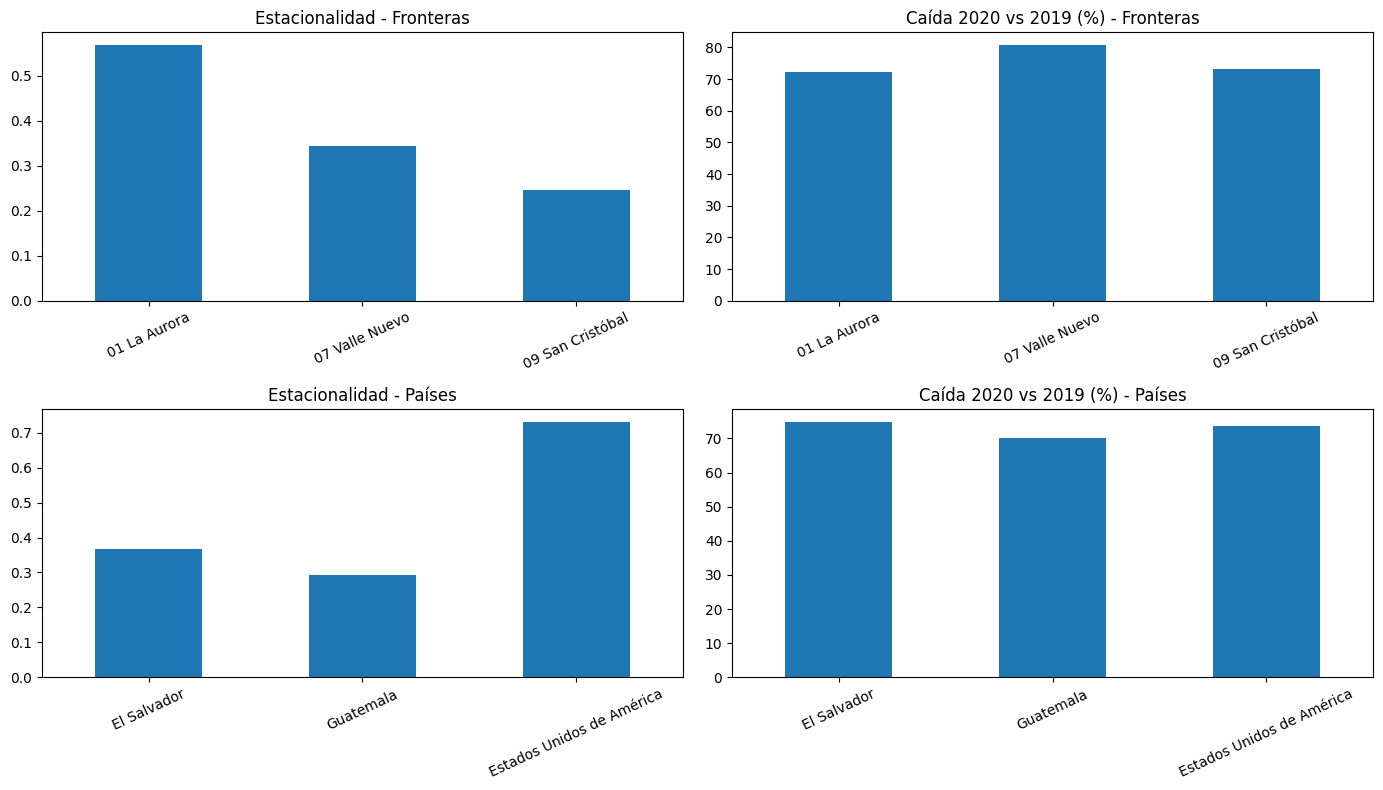

In [36]:
def indicadores_comparativos(serie):
    serie = serie.astype(float).asfreq('MS', fill_value=0)
    componentes = seasonal_decompose(serie, model='additive', period=12)
    validos = pd.concat([componentes.seasonal, componentes.resid], axis=1).dropna()
    fuerza = max(0, 1 - validos.iloc[:, 1].var() / validos.sum(axis=1).var())
    prepandemia = serie.loc[:'2019-12-01']
    pendiente = np.polyfit(np.arange(len(prepandemia)), prepandemia, 1)[0]
    crecimiento = 100 * pendiente / prepandemia.mean()
    volatilidad = 100 * componentes.resid.dropna().std() / serie.mean()
    media_2019 = serie[serie.index.year == 2019].mean()
    media_2020 = serie[serie.index.year == 2020].mean()
    impacto = 100 * (media_2019 - media_2020) / media_2019
    return {
        'fuerza_estacional': fuerza,
        'crecimiento_mensual_pct': crecimiento,
        'volatilidad_pct': volatilidad,
        'caida_pandemia_pct': impacto,
    }

indice_completo = pd.date_range(df['Fecha'].min(), df['Fecha'].max(), freq='MS')
series_frontera_completas = {
    frontera: (df[df['Frontera'] == frontera].groupby('Fecha')['Viajero'].sum()
               .reindex(indice_completo, fill_value=0))
    for frontera in top3_fronteras
}
series_pais_completas = {
    pais: (df[df['País'] == pais].groupby('Fecha')['Viajero'].sum()
           .reindex(indice_completo, fill_value=0))
    for pais in top3_paises
}

comparativos = {}
for categoria, coleccion in [('Fronteras', series_frontera_completas),
                                ('Países', series_pais_completas)]:
    tabla = pd.DataFrame({nombre: indicadores_comparativos(serie)
                          for nombre, serie in coleccion.items()}).T
    comparativos[categoria] = tabla
    print(f'\n{categoria}')
    display(tabla.round(3))
    print('Mayor estacionalidad:', tabla['fuerza_estacional'].idxmax())
    print('Mayor crecimiento:', tabla['crecimiento_mensual_pct'].idxmax())
    print('Mayor volatilidad:', tabla['volatilidad_pct'].idxmax())
    print('Mayor impacto pandémico:', tabla['caida_pandemia_pct'].idxmax())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for fila, (categoria, tabla) in enumerate(comparativos.items()):
    tabla['fuerza_estacional'].plot.bar(ax=axes[fila, 0], title=f'Estacionalidad - {categoria}')
    tabla['caida_pandemia_pct'].plot.bar(ax=axes[fila, 1], title=f'Caída 2020 vs 2019 (%) - {categoria}')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### Hallazgos para la toma de decisiones

Los indicadores anteriores permiten concentrar promoción y capacidad operativa en los meses de mayor estacionalidad, distinguir crecimiento estructural de variación mensual y dimensionar la recuperación posterior a 2020. La Aurora requiere planificación especialmente estacional por su papel aéreo, mientras que las fronteras terrestres reflejan movilidad regional de mayor frecuencia. El Salvador y Estados Unidos de América mantienen cobertura reciente y son más útiles para monitorear mercados. Guatemala no debe usarse para decisiones posteriores a 2022 sin recuperar una fuente compatible, porque el cero observado es metodológico.